# Data Loading

In [2]:
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split, RepeatedKFold

In [3]:
vosoughi_false_df = pd.read_csv('./rq2_vosoughi_False_features.csv', index_col=0, sep=',', encoding='utf-8')
vosoughi_true_df = pd.read_csv('./rq2_vosoughi_True_features.csv', index_col=0, sep=',', encoding='utf-8')
vosoughi_df = pd.concat([vosoughi_false_df, vosoughi_true_df])
# vosoughi_df = vosoughi_true_df
vosoughi_df.shape

(107015, 16)

In [4]:
filtered_df = vosoughi_df[(vosoughi_df.characteristic_distance != -99999) & (vosoughi_df.depth != 0)]
filtered_df.shape

(38007, 16)

In [5]:
filtered_df[(filtered_df.characteristic_distance != -99999) & (filtered_df.depth != 0)].groupby(['veracity']).count()

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance
veracity,,,,,,,,,,,,,,,
0.0,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858,31858
1.0,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149,6149


In [90]:
vosoughi_df[vosoughi_df.cascade_root_id.duplicated()]

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity


In [8]:
filtered_df[filtered_df.structural_heterogeneity == 0.0].shape

(0, 15)

In [6]:
active_features = 15
X = filtered_df.iloc[:,3:active_features]
Y = filtered_df.iloc[:,active_features]
# split data into train and test sets
seed = 7
test_size = 0.15
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

In [8]:
considered_features = ['max_breadth', 'density', 'virality', 'depth', 'structural_heterogeneity', 'characteristic_distance', 'size_of_scc', 'layer_ratio']
X_train[considered_features]

,max_breadth,density,virality,depth,structural_heterogeneity,characteristic_distance,size_of_scc,layer_ratio
76742,15.0,0.050000,0.076316,2.0,1.807954,1.444840,20.0,1.333333
65438,4.0,0.250000,0.250000,1.0,1.154701,3.497332,4.0,1.000000
77936,12.0,0.055556,0.104575,3.0,1.578401,1.031867,18.0,1.416667
62375,3.0,0.333333,0.333333,1.0,1.060660,2.466303,3.0,1.000000
67452,5.0,0.200000,0.200000,1.0,1.250000,4.445556,5.0,1.000000
...,...,...,...,...,...,...,...,...
53331,2.0,0.500000,0.500000,1.0,1.000000,1.439579,2.0,1.000000
2282,2.0,0.333333,0.666667,2.0,1.060660,1.819785,3.0,1.500000
64675,4.0,0.250000,0.250000,1.0,1.154701,3.497332,4.0,1.000000
51667,2.0,0.500000,0.500000,1.0,1.000000,1.439579,2.0,1.000000


In [12]:
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3)

for train_index, val_index in outer_cv.split(X_train_val.to_numpy()):
    X_train, X_val = X_train_val.iloc[train_index, :], X_train_val.iloc[val_index, :]
    y_train, Y_val = y_train_val.iloc[train_index], y_train_val.iloc[val_index]
    print(X_train.shape, y_train.shape, X_val.shape, Y_val.shape)

(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20372, 12) (20372,) (5092, 12) (5092,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20372, 12) (20372,) (5092, 12) (5092,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20371, 12) (20371,) (5093, 12) (5093,)
(20372, 12) (20372,) (5092, 12) (5092,)


In [11]:
# do not run
filtered_df.characteristic_distance.replace(to_replace=-99999, value=float("NaN"), inplace=True)
filtered_df.structural_heterogeneity.replace(to_replace=0.0, value=float("NaN"), inplace=True)

# Data cleaning

In [95]:
filtered_df

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
50748,666884.0,50748.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50749,666886.0,50749.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50750,666889.0,50750.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50751,666891.0,50751.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
50752,666893.0,50752.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6144,4022213.0,88733.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0
6145,4022215.0,88734.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0
6146,4022217.0,88735.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0
6147,4022219.0,88736.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579,1.0


In [7]:
filtered_df[filtered_df['characteristic_distance'] == 0].groupby(['veracity']).count()

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance
veracity,,,,,,,,,,,,,,,
0.0,413,413,413,413,413,413,413,413,413,413,413,413,413,413,413
1.0,12,12,12,12,12,12,12,12,12,12,12,12,12,12,12


In [27]:
filtered_df['characteristic_distance'] = np.log(filtered_df['characteristic_distance'] + np.quantile(filtered_df['characteristic_distance'], 0.25)**2/np.quantile(filtered_df['characteristic_distance'], 0.75))
filtered_df['characteristic_distance'].describe()

c:\Program Files\Python310\lib\site-packages\pandas\core\arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\istiyak\AppData\Local\Temp\ipykernel_11036\4001854548.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['characteristic_distance'] = np.log(filtered_df['characteristic_distance'] + np.quantile(filtered_df['characteristic_distance'], 0.25)**2/np.quantile(filtered_df['characteristic_distance'], 0.75))


count    37582.000000
mean         0.136527
std          0.403604
min         -1.828570
25%          0.008888
50%          0.008888
75%          0.367368
max          3.164701
Name: characteristic_distance, dtype: float64

In [28]:
filtered_df['characteristic_distance'].describe()

count    37582.000000
mean         0.136527
std          0.403604
min         -1.828570
25%          0.008888
50%          0.008888
75%          0.367368
max          3.164701
Name: characteristic_distance, dtype: float64

In [6]:
# https://aosmith.rbind.io/2018/09/19/the-log-0-problem/

from sklearn.preprocessing import StandardScaler
from copy import copy

normalized_df = copy(X_train)
cd_first_quantile = np.quantile(normalized_df['characteristic_distance'], 0.25)
cd_third_quantile = np.quantile(normalized_df['characteristic_distance'], 0.75)
normalized_df['depth'] = np.log(normalized_df['depth'])
normalized_df['size'] = np.log(normalized_df['size'])
normalized_df['max_breadth'] = np.log(normalized_df['max_breadth'])
normalized_df['strongly_cc'] = np.log(normalized_df['strongly_cc'])
# normalized_df['size_of_scc'] = np.log(normalized_df['size_of_scc'])
# normalized_df['structural_heterogeneity'] = np.log(normalized_df['structural_heterogeneity'])
normalized_df['characteristic_distance'] = np.log(normalized_df['characteristic_distance'] + cd_first_quantile**2/cd_third_quantile)
normalized_df = normalized_df.drop(columns=['avg_cluster_coef'], axis=1) 
normalized_df = normalized_df.drop(['weakly_cc'], axis=1)

scaler = StandardScaler().set_output(transform="pandas")
scaled_X_train = scaler.fit_transform(normalized_df)

In [10]:
normalized_df['structural_heterogeneity'].var()

7.930229093781778

In [11]:
normalized_df['structural_heterogeneity'].describe()

count    32305.000000
mean         1.790869
std          2.816066
min          1.000000
25%          1.000000
50%          1.106567
75%          1.428869
max         78.899035
Name: structural_heterogeneity, dtype: float64

In [ ]:
log normalize --> depth, size, max_breadth, strongly_cc, size_of_scc, characteristic_distance
remove --> weakly_cc

In [11]:
filtered_df['characteristic_distance'].max()

13235162895.68282

In [9]:
filtered_df['size'].describe()

count    38007.000000
mean        96.263451
std        979.578537
min          2.000000
25%          2.000000
50%          4.000000
75%          9.000000
max      46895.000000
Name: size, dtype: float64

In [10]:
filtered_df['size'].var()

959574.1095895498

In [99]:
filtered_df['size'].describe()

count    38007.000000
mean        96.263451
std        979.578537
min          2.000000
25%          2.000000
50%          4.000000
75%          9.000000
max      46895.000000
Name: size, dtype: float64

In [100]:
filtered_df['size'].var()

959574.1095895498

In [101]:
filtered_df['size'] = np.log(filtered_df['size'])

2.1748864326654336

In [10]:
len(list(scaled_X_train.columns))

10

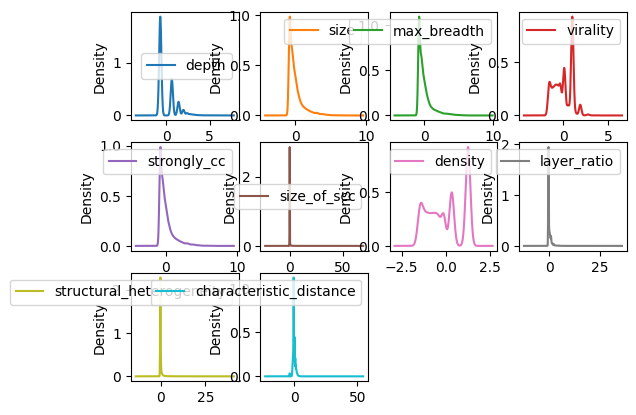

In [12]:
import matplotlib.pyplot as plt
scaled_X_train.plot(kind='density', subplots=True, layout=(3,4), sharex=False, sharey=False)
plt.show()

[Text(0, 0, 'depth'),
 Text(1, 0, 'size'),
 Text(2, 0, 'max_breadth'),
 Text(3, 0, 'virality'),
 Text(4, 0, 'strongly_cc'),
 Text(5, 0, 'size_of_scc'),
 Text(6, 0, 'density'),
 Text(7, 0, 'layer_ratio'),
 Text(8, 0, 'structural_heterogeneity'),
 Text(9, 0, 'characteristic_distance')]

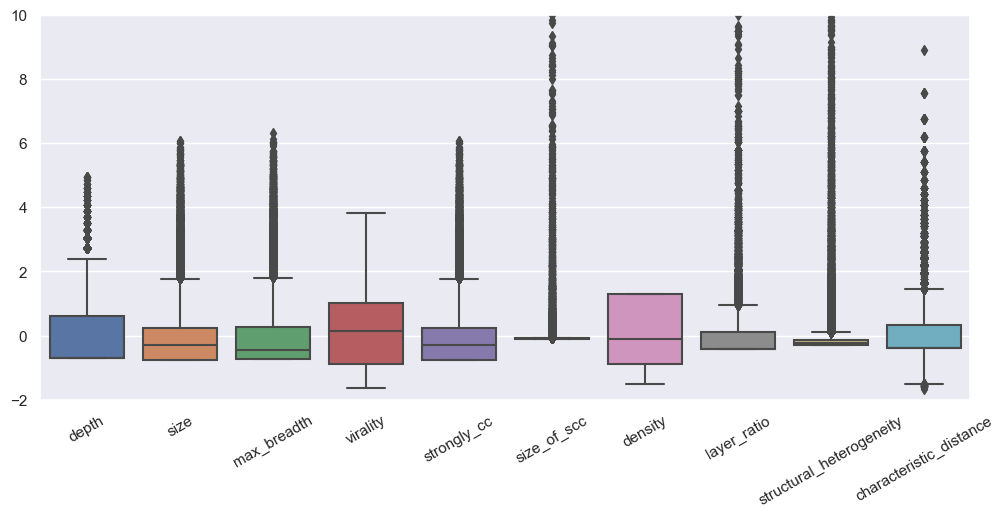

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.cbook import boxplot_stats

d = [boxplot_stats(scaled_X_train[col].dropna().values)[0] for col in scaled_X_train.columns]
s = pd.DataFrame(d, index=scaled_X_train.columns).iloc[:, [4, 5, 7, 8, 9]].round(2)

# sns.set(rc={'figure.figsize':(15, 10)})

fig, ax = plt.subplots(figsize=(12, 5))
ax.set(ylim=(-2, 10))
# directly plot the wide dataframe with only the total_bill data
box_plot = sns.boxplot(data=scaled_X_train, ax=ax)

box_plot.set_xticklabels(box_plot.get_xticklabels(), rotation=30)

# for xtick in box_plot.get_xticks():
#     for col in s.columns:
#         box_plot.text(xtick, s[col][xtick], s[col][xtick], horizontalalignment='left', size='medium', color='k', weight='semibold', bbox=dict(facecolor='lightgray'))


# plt.yscale('log')
# plt.show()
# plt.savefig('train_data_dist.eps')


In [111]:
from matplotlib.cbook import boxplot_stats

d = [boxplot_stats(scaled_X_train[col].dropna().values)[0] for col in scaled_X_train.columns]
s = pd.DataFrame(d, index=scaled_X_train.columns).iloc[:, [4, 5, 7, 8, 9]].round(2)

s["mean"]=scaled_X_train.mean()
s["Var"]=scaled_X_train.var()
s


,whishi,whislo,q1,med,q3,mean,Var
depth,2.38,-0.71,-0.71,-0.71,0.62,1.196518e-16,1.000031
size,1.78,-0.78,-0.78,-0.31,0.25,2.023524e-17,1.000031
max_breadth,1.81,-0.74,-0.74,-0.44,0.28,2.744954e-16,1.000031
virality,3.81,-1.63,-0.88,0.13,1.02,2.230275e-16,1.000031
strongly_cc,1.78,-0.78,-0.78,-0.31,0.25,2.023524e-17,1.000031
size_of_scc,-0.08,-0.09,-0.09,-0.09,-0.09,-6.268524e-18,1.000031
density,1.28,-1.50,-0.88,-0.11,1.28,3.211244e-17,1.000031
layer_ratio,0.94,-0.42,-0.42,-0.42,0.12,9.149846e-17,1.000031
structural_heterogeneity,0.10,-0.28,-0.28,-0.24,-0.13,-5.014819e-17,1.000031
characteristic_distance,1.44,-1.50,-0.40,-0.40,0.34,-3.206845e-16,1.000031


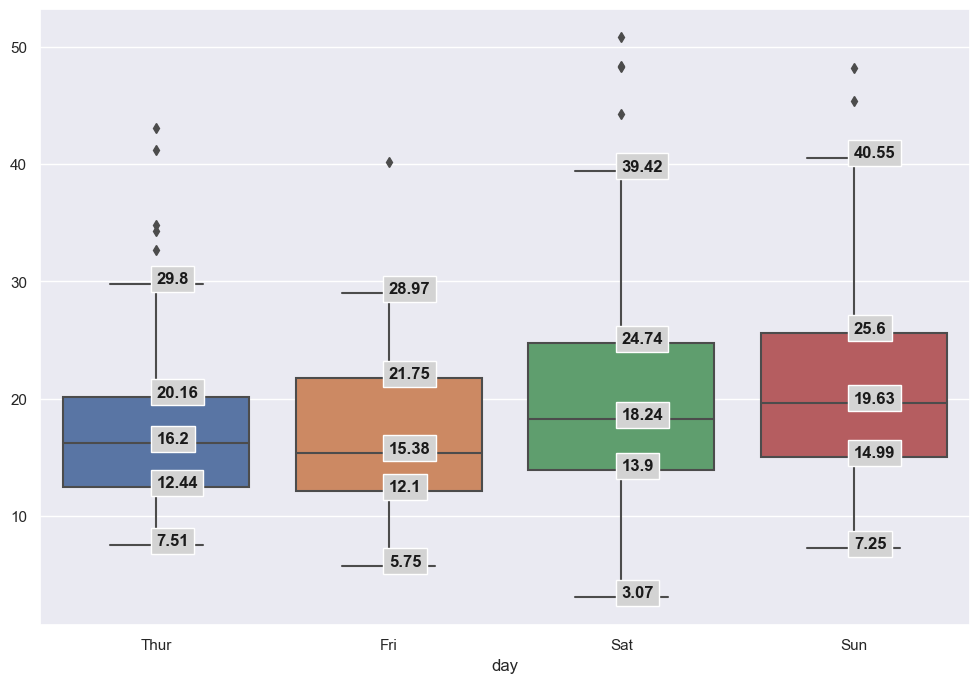

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.cbook import boxplot_stats

# load sample data
tips = sns.load_dataset("tips")

# 1. pivot tips so there's a column for each day for total_bill
days_total_bill = tips.pivot(columns='day', values='total_bill')
# 2. extract the boxplot stats for each day
days_total_bill_stats = [boxplot_stats(days_total_bill[col].dropna().values)[0] for col in days_total_bill.columns]
# 3. create a dataframe for the stats for each day
stats = pd.DataFrame(days_total_bill_stats, index=days_total_bill.columns).iloc[:, [4, 5, 7, 8, 9]].round(2)

# plot
fig, ax = plt.subplots(figsize=(12, 8))
# directly plot the wide dataframe with only the total_bill data
box_plot = sns.boxplot(data=days_total_bill, ax=ax)

# same plot is created with the primary tips dataframe
# box_plot = sns.boxplot(x="day", y="total_bill", data=tips, ax=ax)

# annotate
for xtick in box_plot.get_xticks():
    for col in stats.columns:
        box_plot.text(xtick, stats[col][xtick], stats[col][xtick], horizontalalignment='left', size='medium', color='k', weight='semibold', bbox=dict(facecolor='lightgray'))

In [48]:
days_total_bill_stats

[{'mean': 17.682741935483868,
  'iqr': 7.712500000000002,
  'cilo': 14.662203087202318,
  'cihi': 17.73779691279768,
  'whishi': 29.8,
  'whislo': 7.51,
  'fliers': array([32.68, 34.83, 34.3 , 41.19, 43.11]),
  'q1': 12.442499999999999,
  'med': 16.2,
  'q3': 20.155},
 {'mean': 17.15157894736842,
  'iqr': 9.655000000000001,
  'cilo': 11.902436010483171,
  'cihi': 18.85756398951683,
  'whishi': 28.97,
  'whislo': 5.75,
  'fliers': array([40.17]),
  'q1': 12.094999999999999,
  'med': 15.38,
  'q3': 21.75},
 {'mean': 20.441379310344825,
  'iqr': 10.835,
  'cilo': 16.4162347275501,
  'cihi': 20.063765272449896,
  'whishi': 39.42,
  'whislo': 3.07,
  'fliers': array([48.27, 44.3 , 50.81, 48.33]),
  'q1': 13.905000000000001,
  'med': 18.24,
  'q3': 24.740000000000002},
 {'mean': 21.41,
  'iqr': 10.610000000000001,
  'cilo': 17.719230764952172,
  'cihi': 21.540769235047826,
  'whishi': 40.55,
  'whislo': 7.25,
  'fliers': array([48.17, 45.35]),
  'q1': 14.987499999999999,
  'med': 19.63,
  'q

# New Section

In [13]:
vosoughi_df

In [ ]:
columns = ['cascade_id','depth','size','max_breadth','virality','strongly_cc','weakly_cc','size_of_scc','avg_cluster_coef','density','layer_ratio','structural_heterogeneity','characteristic_distance','veracity']
vosoughi_df[vosoughi_df.virality.isna() == True][columns].to_csv('./trial.csv', sep=',', encoding='utf-8')


In [6]:
filtered_df[filtered_df.virality.isna() == False]

,cascade_root_id,cascade_id,time_bucket,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,avg_cluster_coef,density,layer_ratio,structural_heterogeneity,characteristic_distance,veracity
50748,666884.0,50748.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50749,666886.0,50749.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50750,666889.0,50750.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50751,666891.0,50751.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
50752,666893.0,50752.0,4034725.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6144,4022213.0,88733.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0
6145,4022215.0,88734.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0
6146,4022217.0,88735.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0
6147,4022219.0,88736.0,4034735.0,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.0,0.5,1.0,1.0,1.439579,1.0


(38007, 15)

In [14]:
filtered_df.iloc[:,3:14]

,depth,size,max_breadth,virality,strongly_cc,weakly_cc,size_of_scc,density,layer_ratio,structural_heterogeneity,characteristic_distance
50748,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
50749,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
50750,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
50751,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
50752,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
...,...,...,...,...,...,...,...,...,...,...,...
6144,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
6145,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
6146,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579
6147,1.0,2.0,2.0,0.5,2.0,1.0,2.0,0.5,1.0,1.0,1.439579


In [6]:
from numpy import loadtxt
# from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import balanced_accuracy_score, accuracy_score

In [ ]:
# load data
# dataset = pd.read_csv('pima-indians-diabetes.csv', header=None, sep=",")

In [7]:
X = filtered_df.iloc[:,3:14]
Y = filtered_df.iloc[:,14]

In [17]:
# Y

In [8]:
# split data into train and test sets
seed = 7
test_size = 0.33
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=test_size, random_state=seed)

In [14]:
from sklearn.model_selection import RepeatedKFold, GridSearchCV
outer_cv = RepeatedKFold(n_splits=5, n_repeats=2)
i = 0
for train_index, val_index in outer_cv.split(X_train.to_numpy()):
    print(i)
    i+=1 

0
1
2
3
4
5
6
7
8
9


In [ ]:
# fit model no training data
model = XGBClassifier()
model.fit(X_train, y_train)

In [ ]:
print(model)

In [ ]:
# make predictions for test data
y_pred = model.predict(X_test)
predictions = [round(value) for value in y_pred]

In [27]:
from time import time 
from sklearn.metrics import average_precision_score, balanced_accuracy_score, accuracy_score
from sklearn.model_selection import RepeatedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

In [33]:
outer_cv = RepeatedKFold(n_splits=5, n_repeats=1)
i = 0
for train_index, val_index in outer_cv.split(X.to_numpy()):
    print(i)
    i += 1

0
1
2
3
4


In [15]:
# Decision Tree 



start = time()

dt_param = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'splitter': ['best', 'random'],
    'max_depth': [4, 5, 6, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [4, 5, 6, 7],
}


i = 0
avg_pr_scores = []
ba_scores = []
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3)

over = SMOTE(sampling_strategy=0.5)
under = RandomUnderSampler(sampling_strategy=0.5)
X, Y = over.fit_resample(filtered_df.iloc[:,3:14].to_numpy(), filtered_df.iloc[:,14].to_numpy())
# X, Y = under.fit_resample(X, Y)

for train_val_index, test_index in outer_cv.split(filtered_df.iloc[:,3:15].to_numpy()):
  
  X_train_val = X[train_val_index]
  Y_train_val = Y[train_val_index]
  X_test = X[test_index]
  Y_test = Y[test_index]

  dt_clf = DecisionTreeClassifier(random_state=0)

  inner_cv = RepeatedKFold(n_splits=5, n_repeats=3)
    
  pipeline = Pipeline([
            ('std_scaler',StandardScaler()),
        ])

  X_train_val = pipeline.fit_transform(X_train_val)
  X_test = pipeline.transform(X_test)
  
  clf = GridSearchCV(
    estimator = dt_clf,
    cv = inner_cv, 
    refit=True, 
    param_grid=dt_param,
    scoring='accuracy'
  )

  result = clf.fit(X_train_val, Y_train_val)
  best_model = result.best_estimator_
  Y_pred = best_model.predict(X_test)
  ba_score = accuracy_score(Y_test, Y_pred)
  # pr_score = average_precision_score(Y_test, Y_pred)
  # avg_pr_scores.append(pr_score)
  ba_scores.append(ba_score)

  print('>acc=%.4f, est=%.4f, cfg=%s' % (ba_score, result.best_score_, result.best_params_))
  i += 1
  
# print('PR AUC: %.3f %.3f, BA: %.3f %.3f' % (np.mean(avg_pr_scores), np.std(avg_pr_scores), np.mean(ba_scores), np.std(ba_scores)))
print('Acc: %.3f %.3f' % (np.mean(ba_scores), np.std(ba_scores)))
end = time()
print("Fit Time:", end - start)

>acc=0.8328, est=0.8396, cfg={'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'random'}


KeyboardInterrupt: 

In [15]:
from sklearn.svm import SVC

svc_params = {

    'C': [0.1], 
    # 'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    # 'degree': [_ for _ in range(1, 5, 1)],
    # 'gamma': ['scale', 'auto'],
    # 'decision_function_shape': ['ovo', 'ovr'],
    # 'shrinking': [True, False],
    # 'coef0': [0.0, 0.1, 0.01, 0.5, 1]
}

i = 0
avg_pr_scores = []
ba_scores = []
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3)

over = SMOTE(sampling_strategy=0.5)
under = RandomUnderSampler(sampling_strategy=0.5)
X, Y = over.fit_resample(filtered_df.iloc[:,3:14].to_numpy(), filtered_df.iloc[:,14].to_numpy())
# X, Y = under.fit_resample(X, Y)

for train_val_index, test_index in outer_cv.split(filtered_df.iloc[:,3:15].to_numpy()):
  
  X_train_val = X[train_val_index]
  Y_train_val = Y[train_val_index]
  X_test = X[test_index]
  Y_test = Y[test_index]

  svc_model = SVC()

  inner_cv = RepeatedKFold(n_splits=5, n_repeats=3)
    
  pipeline = Pipeline([
            ('std_scaler',StandardScaler()),
        ])

  X_train_val = pipeline.fit_transform(X_train_val)
  X_test = pipeline.transform(X_test)
  
  clf = GridSearchCV(
    estimator = svc_model,
    cv = inner_cv, 
    refit=True, 
    param_grid=svc_params,
    scoring='accuracy'
  )

  result = clf.fit(X_train_val, Y_train_val)
  best_model = result.best_estimator_
  Y_pred = best_model.predict(X_test)
  ba_score = accuracy_score(Y_test, Y_pred)
  pr_score = average_precision_score(Y_test, Y_pred)
  avg_pr_scores.append(pr_score)
  ba_scores.append(ba_score)

  print('>ba=%.4f, pr=%.4f, est=%.4f, cfg=%s' % (ba_score, pr_score, result.best_score_, result.best_params_))
  i += 1
  
print('PR AUC: %.3f %.3f, BA: %.3f %.3f' % (np.mean(avg_pr_scores), np.std(avg_pr_scores), np.mean(ba_scores), np.std(ba_scores)))
end = time()
print("Fit Time:", end - start)

>ba=0.8412, pr=0.1588, est=0.8375, cfg={'C': 0.1}


KeyboardInterrupt: 

In [10]:
#random forest

from sklearn.ensemble import RandomForestClassifier


rf_params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    # 'max_depth': [_ for _ in range(1, 10, 1)],
    # 'max_features': ['sqrt', 'log2', None], 
    # 'min_samples_split': [_ for _ in range(1, 10, 1)],
    # 'min_samples_leaf': [_ for _ in range(1, 10, 1)],    
}

i = 0
avg_pr_scores = []
ba_scores = []
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3)

over = SMOTE(sampling_strategy=0.5)
under = RandomUnderSampler(sampling_strategy=0.5)
X, Y = over.fit_resample(filtered_df.iloc[:,3:14].to_numpy(), filtered_df.iloc[:,14].to_numpy())
# X, Y = under.fit_resample(X, Y)

for train_val_index, test_index in outer_cv.split(filtered_df.iloc[:,3:15].to_numpy()):
  
  X_train_val = X[train_val_index]
  Y_train_val = Y[train_val_index]
  X_test = X[test_index]
  Y_test = Y[test_index]

  rf_model = RandomForestClassifier()

  inner_cv = RepeatedKFold(n_splits=5, n_repeats=3)
    
  pipeline = Pipeline([
            ('std_scaler',StandardScaler()),
        ])

  X_train_val = pipeline.fit_transform(X_train_val)
  X_test = pipeline.transform(X_test)
  
  clf = GridSearchCV(
    estimator = rf_model,
    cv = inner_cv, 
    refit=True, 
    param_grid=rf_params,
    scoring='accuracy'
  )

  result = clf.fit(X_train_val, Y_train_val)
  best_model = result.best_estimator_
  Y_pred = best_model.predict(X_test)
  ba_score = accuracy_score(Y_test, Y_pred)
  pr_score = average_precision_score(Y_test, Y_pred)
  avg_pr_scores.append(pr_score)
  ba_scores.append(ba_score)

  print('>ba=%.4f, pr=%.4f, est=%.4f, cfg=%s' % (ba_score, pr_score, result.best_score_, result.best_params_))
  i += 1
  
print('PR AUC: %.3f %.3f, BA: %.3f %.3f' % (np.mean(avg_pr_scores), np.std(avg_pr_scores), np.mean(ba_scores), np.std(ba_scores)))
end = time()
print("Fit Time:", end - start)

>ba=0.8312, pr=0.1636, est=0.8321, cfg={'criterion': 'gini'}
>ba=0.8353, pr=0.1581, est=0.8317, cfg={'criterion': 'gini'}


KeyboardInterrupt: 

In [13]:
np.logspace(0,-9, num=2)

array([1.e+00, 1.e-09])

In [14]:
# naive bayes

from sklearn.naive_bayes import GaussianNB

nb_params = {
    'var_smoothing': np.logspace(0,-9, num=1)
}

i = 0
avg_pr_scores = []
ba_scores = []
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3)

over = SMOTE(sampling_strategy=0.5)
under = RandomUnderSampler(sampling_strategy=0.5)
X, Y = over.fit_resample(filtered_df.iloc[:,3:14].to_numpy(), filtered_df.iloc[:,14].to_numpy())
# X, Y = under.fit_resample(X, Y)

for train_val_index, test_index in outer_cv.split(filtered_df.iloc[:,3:15].to_numpy()):
  
  X_train_val = X[train_val_index]
  Y_train_val = Y[train_val_index]
  X_test = X[test_index]
  Y_test = Y[test_index]

  nb_classifier = GaussianNB()

  inner_cv = RepeatedKFold(n_splits=5, n_repeats=3)
    
  pipeline = Pipeline([
            ('std_scaler',StandardScaler()),
        ])

  X_train_val = pipeline.fit_transform(X_train_val)
  X_test = pipeline.transform(X_test)
  
  clf = GridSearchCV(
    estimator = nb_classifier,
    cv = inner_cv, 
    refit=True, 
    param_grid=nb_params,
    scoring='accuracy'
  )

  result = clf.fit(X_train_val, Y_train_val)
  best_model = result.best_estimator_
  Y_pred = best_model.predict(X_test)
  ba_score = accuracy_score(Y_test, Y_pred)
  pr_score = average_precision_score(Y_test, Y_pred)
  avg_pr_scores.append(pr_score)
  ba_scores.append(ba_score)

  print('>ba=%.4f, pr=%.4f, est=%.4f, cfg=%s' % (ba_score, pr_score, result.best_score_, result.best_params_))
  i += 1
  
print('PR AUC: %.3f %.3f, BA: %.3f %.3f' % (np.mean(avg_pr_scores), np.std(avg_pr_scores), np.mean(ba_scores), np.std(ba_scores)))
end = time()
print("Fit Time:", end - start)

>ba=0.2067, pr=0.1630, est=0.2729, cfg={'var_smoothing': 1.0}
>ba=0.2490, pr=0.1574, est=0.3011, cfg={'var_smoothing': 1.0}
>ba=0.2209, pr=0.1730, est=0.3030, cfg={'var_smoothing': 1.0}
>ba=0.2083, pr=0.1613, est=0.2836, cfg={'var_smoothing': 1.0}
>ba=0.2104, pr=0.1631, est=0.2656, cfg={'var_smoothing': 1.0}
>ba=0.2086, pr=0.1654, est=0.2854, cfg={'var_smoothing': 1.0}
>ba=0.2053, pr=0.1593, est=0.2469, cfg={'var_smoothing': 1.0}
>ba=0.2051, pr=0.1580, est=0.2668, cfg={'var_smoothing': 1.0}
>ba=0.2184, pr=0.1718, est=0.3039, cfg={'var_smoothing': 1.0}
>ba=0.2698, pr=0.1650, est=0.3313, cfg={'var_smoothing': 1.0}
>ba=0.2110, pr=0.1618, est=0.2891, cfg={'var_smoothing': 1.0}
>ba=0.2113, pr=0.1632, est=0.2864, cfg={'var_smoothing': 1.0}
>ba=0.2121, pr=0.1685, est=0.2807, cfg={'var_smoothing': 1.0}
>ba=0.2471, pr=0.1625, est=0.2843, cfg={'var_smoothing': 1.0}
>ba=0.2094, pr=0.1643, est=0.2615, cfg={'var_smoothing': 1.0}
PR AUC: 0.164 0.004, BA: 0.220 0.019


NameError: name 'start' is not defined

In [11]:
# logistic regression


from sklearn.linear_model import LogisticRegression


logit_params = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    # 'dual': [True, False],
    # 'C': [_ for _ in range(1, 10, 1)],
    # 'fit_intercept': [True, False],
    # 'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    # 'n_jobs': -1
}

i = 0
avg_pr_scores = []
ba_scores = []
outer_cv = RepeatedKFold(n_splits=5, n_repeats=3)

over = SMOTE(sampling_strategy=0.5)
under = RandomUnderSampler(sampling_strategy=0.5)
X, Y = over.fit_resample(filtered_df.iloc[:,3:14].to_numpy(), filtered_df.iloc[:,14].to_numpy())
# X, Y = under.fit_resample(X, Y)

for train_val_index, test_index in outer_cv.split(filtered_df.iloc[:,3:15].to_numpy()):
  
  X_train_val = X[train_val_index]
  Y_train_val = Y[train_val_index]
  X_test = X[test_index]
  Y_test = Y[test_index]

  logit_model = LogisticRegression()

  inner_cv = RepeatedKFold(n_splits=5, n_repeats=3)
    
  pipeline = Pipeline([
            ('std_scaler',StandardScaler()),
        ])

  X_train_val = pipeline.fit_transform(X_train_val)
  X_test = pipeline.transform(X_test)
  
  clf = GridSearchCV(
    estimator = logit_model,
    cv = inner_cv, 
    refit=True, 
    param_grid=logit_params,
    scoring='accuracy'
  )

  result = clf.fit(X_train_val, Y_train_val)
  best_model = result.best_estimator_
  Y_pred = best_model.predict(X_test)
  ba_score = accuracy_score(Y_test, Y_pred)
  pr_score = average_precision_score(Y_test, Y_pred)
  avg_pr_scores.append(pr_score)
  ba_scores.append(ba_score)

  print('>ba=%.4f, pr=%.4f, est=%.4f, cfg=%s' % (ba_score, pr_score, result.best_score_, result.best_params_))
  i += 1
  
print('PR AUC: %.3f %.3f, BA: %.3f %.3f' % (np.mean(avg_pr_scores), np.std(avg_pr_scores), np.mean(ba_scores), np.std(ba_scores)))
end = time()
print("Fit Time:", end - start)

c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 54, in _check_solver
    raise ValueErro

>ba=0.8377, pr=0.1623, est=0.8383, cfg={'penalty': 'l2'}


c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 54, in _check_solver
    raise ValueErro

>ba=0.8410, pr=0.1590, est=0.8374, cfg={'penalty': 'l2'}


c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 54, in _check_solver
    raise ValueErro

...

c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 54, in _check_solver
    raise ValueErro

>ba=0.8429, pr=0.1574, est=0.8370, cfg={'penalty': 'l2'}


c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
30 fits failed out of a total of 60.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 54, in _check_solver
    raise ValueErro

>ba=0.8316, pr=0.1680, est=0.8397, cfg={'penalty': 'l2'}


KeyboardInterrupt: 

In [ ]:
import sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression
logit_model = LogisticRegression()

logit_params = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'dual': [True, False],
    'C': [_ for _ in range(1, 10, 1)],
    'fit_intercept': [True, False],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'n_jobs': -1
}

# from sklearn.linear_model import RidgeClassifier

# ridge_model = RidgeClassifier()

# ridge_params = {
#     'penalty': ['l1', 'l2', 'elasticnet', None],
#     'dual': [True, False],
#     'C': [_ for _ in range(1, 10, 1)],
#     'fit_intercept': [True, False],
#     'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
#     'n_jobs': -1
# }

In [ ]:
x = [_ for _ in range(1, 15, 1)]
x

In [ ]:
import xgboost as xgb

estimator = xgb.XGBClassifier(
    objective= 'binary:hinge',
    nthread=4,
    seed=42
)

parameters = {
    'max_depth': range (2, 10, 1),
    'n_estimators': range(60, 220, 40),
    'learning_rate': [0.1, 0.01, 0.05],
    'booster': ['gbtree', 'gblinear', 'dart'],
    'max_depth': [6],
    'min_child_weight': [11],
    'subsample': [0.8],
    'colsample_bytree': [0.7],
}

grid_search = GridSearchCV(
    estimator=estimator,
    param_grid=parameters,
    scoring = 'roc_auc',
    n_jobs = 10,
    cv = 10,
    verbose=True
)

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

clf1 = LogisticRegression(random_state=1)
clf2 = RandomForestClassifier(n_estimators=50, random_state=1)
clf3 = GaussianNB()

X = np.array([[-1, -1], [-2, -1], [-3, -2], [1, 1], [2, 1], [3, 2]])
y = np.array([1, 1, 1, 2, 2, 2])

eclf1 = VotingClassifier(estimators=[
        ('lr', clf1), 
        ('rf', clf2), 
        ('gnb', clf3)], 
        voting='hard'
)

eclf1 = eclf1.fit(X, y)
print(eclf1.predict(X))

np.array_equal(eclf1.named_estimators_.lr.predict(X),
               eclf1.named_estimators_['lr'].predict(X))

eclf2 = VotingClassifier(estimators=[
        ('lr', clf1), ('rf', clf2), ('gnb', clf3)],
        voting='soft')
eclf2 = eclf2.fit(X, y)
print(eclf2.predict(X))

In [ ]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool

X_tr, X_eval = train_test_split(df)

y_tr = df_tr.species
y_tr_clean = y_tr == 'virginica'
X_tr.drop(columns=['species', 'target'], inplace=True)

y_eval =  X_eval.species
y_eval_clean = y_eval == 'virginica'
X_eval = X_eval.drop(columns=['species', 'target'])

train_dataset = Pool(X_tr, y_tr_clean, feature_names=list(X_tr.columns))

model_params = {
    'iterations': 10, 
    'loss_function': 'Logloss',
    'train_dir': 'crossentropy',
    'allow_writing_files': False,
    'random_seed': 42,
}

model = CatBoostClassifier(**model_params)
model.fit(train_dataset, verbose=True, plot=True)

In [ ]:
dt_clf = DecisionTreeClassifier(random_state=0)

dt_param = {
    'criterion': {'gini', 'entropy', 'log_loss'},
    'splitter': {'best', 'random'},
    'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [_ for _ in range(1, 10, 1)],
}

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

dt_clf = DecisionTreeClassifier(random_state=0)

dt_param = {
    'criterion': {'gini', 'entropy', 'log_loss'},
    'splitter': {'best', 'random'},
    'max_depth': [4, 5, 6, 7, 8, 9, 10, 11, 12, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [_ for _ in range(1, 10, 1)],
}

svc_model = SVC()

svc_params = {

    'C': [0.1, 0.5, 1, 2, 5, 10, 20, 50, 100], 
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid', 'precomputed'],
    'degree': [_ for _ in range(1, 5, 1)],
    'gamma': ['scale', 'auto'],
    'decision_function_shape': {'ovo', 'ovr'},
    'shrinking': [True, False],
    'coef0': [0.0, 0.1, 0.01, 0.5, 1]
}

rf_model = RandomForestClassifier()
rf_params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': [_ for _ in range(1, 10, 1)],
    'max_features': ['sqrt', 'log2', None], 
    'n_jobs': -1,
    'min_samples_split': [_ for _ in range(1, 10, 1)],
    'min_samples_leaf': [_ for _ in range(1, 10, 1)],    
}

nb_classifier = GaussianNB()
nb_params = {
    'var_smoothing': np.logspace(0,-9, num=10)
}

logit_model = LogisticRegression()

logit_params = {
    'penalty': ['l1', 'l2', 'elasticnet', None],
    'dual': [True, False],
    'C': [_ for _ in range(1, 10, 1)],
    'fit_intercept': [True, False],
    'solver': ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    'n_jobs': -1
}

In [ ]:
from sklearn.model_selection import train_test_split

start = time()
rf = RandomForestRegressor(random_state = 42)

params = {
    'bootstrap': [True, False],
    'max_depth': [10, 20, 30],
    # 'max_features': ['auto', 'sqrt'],
    # 'min_samples_leaf': [1, 2, 4],
    # 'min_samples_split': [2, 5, 10],
    # 'n_estimators': [200, 400, 1000],
    'criterion': ['mae'],
    'n_jobs': [-1],
    'random_state': [42]
}

mae_scores = list()
outer_cv = TimeSeriesSplit(n_splits=5)

for train_val_index, test_index in outer_cv.split(data[['var1(t-1)', 'var1(t)']].to_numpy()):
  
  X_train_val = data[['var1(t-1)']].to_numpy()[train_val_index]
  Y_train_val = data[['var1(t)']].to_numpy()[train_val_index]
  X_test = data[['var1(t-1)']].to_numpy()[test_index]
  Y_test = data[['var1(t)']].to_numpy()[test_index]

  inner_cv = TimeSeriesSplit(n_splits=5)
  clf = GridSearchCV(estimator = rf, cv = inner_cv, refit=True, param_grid=params)
  result = clf.fit(X_train_val, Y_train_val)
  best_model = result.best_estimator_
  Y_pred = best_model.predict(X_test)
  score = mean_absolute_error(Y_test, Y_pred)
  mae_scores.append(score)
  print('>acc=%.4f, est=%.4f, cfg=%s' % (score, result.best_score_, result.best_params_))
  with open(BASE_PATH + 'models/model_'+str(score)+'.pickle', 'wb') as handle:
    pickle.dump(best_model, handle, protocol=pickle.HIGHEST_PROTOCOL)

print('MAE: %.3f (%.3f)' % (np.mean(mae_scores), np.std(mae_scores)))
end = time()
print("Fit Time:", end - start)

In [3]:
import numpy as np
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import precision_recall_curve, roc_curve
from sklearn.preprocessing import label_binarize

import matplotlib.pyplot as plt
#%matplotlib inline

mnist = fetch_openml("mnist_784")
y = mnist.target
y = y.astype(np.uint8)
n_classes = len(set(y))

Y = label_binarize(mnist.target, classes=[*range(n_classes)])

X_train, X_test, y_train, y_test = train_test_split(mnist.data,
                                                    Y,
                                                    random_state = 42)

clf = OneVsRestClassifier(RandomForestClassifier(n_estimators=50,
                             max_depth=3,
                             random_state=0))
clf.fit(X_train, y_train)

y_score = clf.predict_proba(X_test)


c:\Program Files\Python310\lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(
c:\Program Files\Python310\lib\site-packages\sklearn\multiclass.py:77: UserWarning: Label not 0 is present in all training examples.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\multiclass.py:77: UserWarning: Label not 1 is present in all training examples.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\multiclass.py:77: UserWarning: Label not 2 is present in all training examples.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\multiclass.py:77: UserWarning: Labe

c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:891: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:891: Us

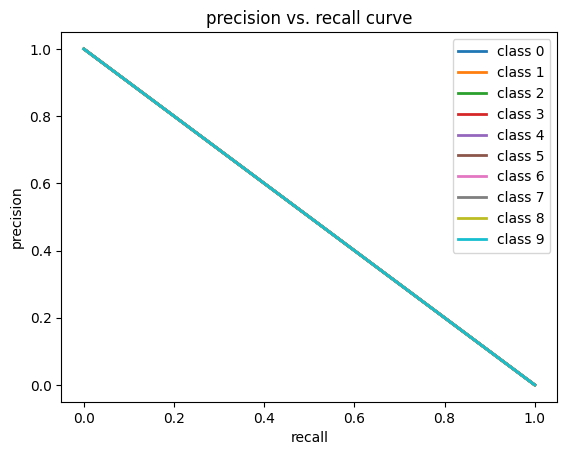

In [4]:

# precision recall curve
precision = dict()
recall = dict()
for i in range(n_classes):
    precision[i], recall[i], _ = precision_recall_curve(y_test[:, i],
                                                        y_score[:, i])
    plt.plot(recall[i], precision[i], lw=2, label='class {}'.format(i))
    
plt.xlabel("recall")
plt.ylabel("precision")
plt.legend(loc="best")
plt.title("precision vs. recall curve")
plt.show()

c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Program Files\Python310\lib\site-packages\sklearn\metrics\_ranking.py:1029: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
c:\Program Files\Python310\lib\site

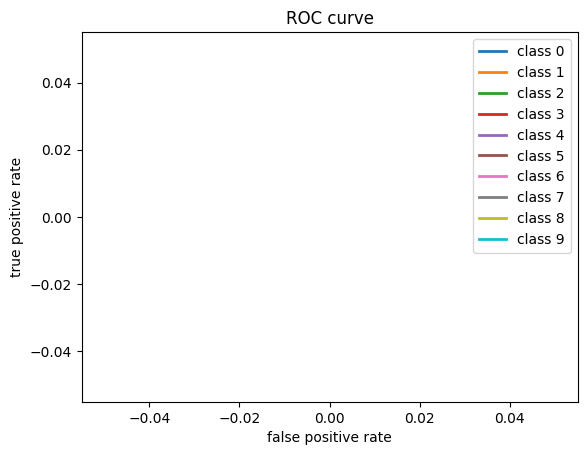

In [6]:
# roc curve
fpr = dict()
tpr = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i],
                                  y_score[:, i])
    plt.plot(fpr[i], tpr[i], lw=2, label='class {}'.format(i))

plt.xlabel("false positive rate")
plt.ylabel("true positive rate")
plt.legend(loc="best")
plt.title("ROC curve")
plt.show()

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier

In [24]:
X[X.virality.isna() == False].shape

(38007, 12)

In [35]:
#create dataset with 5 predictor variables
X, y = datasets.make_classification(n_samples=1000,
                                    n_features=4,
                                    n_informative=3,
                                    n_redundant=1,
                                    random_state=0)

#split dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3,random_state=0)

#fit logistic regression model to dataset
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

#use logistic regression model to make predictions
y_score = classifier.predict_proba(X_test)[:, 1]
pred_proba = classifier.predict_proba(X_test)

In [75]:
# scores = classifier.predict_proba(X_test)
# scores[:, 0]
# # scores

In [39]:
pred_proba = classifier.predict_proba(X_test)
# pred_proba

In [14]:
X_test.shape, pred_proba.shape, pred_proba[:, 1].shape

((300, 4), (300, 2), (300,))

In [4]:
y_score = classifier.predict_proba(X_test)[:, 0]
y_test = [1 if y == 0 else 0 for y in y_test]

In [92]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    fbeta_score,
    average_precision_score,
    precision_score,
    recall_score,
    sensi,
)

y_pred = classifier.predict(X_test)
precision_recall_fscore_support(y_test, y_pred, beta=0.5)


class CustomScore:
    def __init__(
        self, accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision
    ) -> None:
        self.accuracy = accuracy
        self.precision = precision
        self.recall = recall
        self.balanced_accuracy = balanced_accuracy
        self.fbeta = fbeta
        self.avg_precision = avg_precision


def get_precision_recall_fbeta_ba_scores(y_real, y_pred, y_scores) -> CustomScore:
    accuracy = accuracy_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred)
    recall = recall_score(y_real, y_pred)
    balanced_accuracy = balanced_accuracy_score(y_real, y_pred)
    fbeta = fbeta_score(y_real, y_pred, beta=0.5)
    avg_precision = average_precision_score(y_real, y_scores)

    return CustomScore(
        accuracy, precision, recall, balanced_accuracy, fbeta, avg_precision
    )

(array([0.69333333, 0.72      ]),
 array([0.71232877, 0.7012987 ]),
 array([0.69705094, 0.71618037]),
 array([146, 154], dtype=int64))

In [95]:
y_test[:, 0]

IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

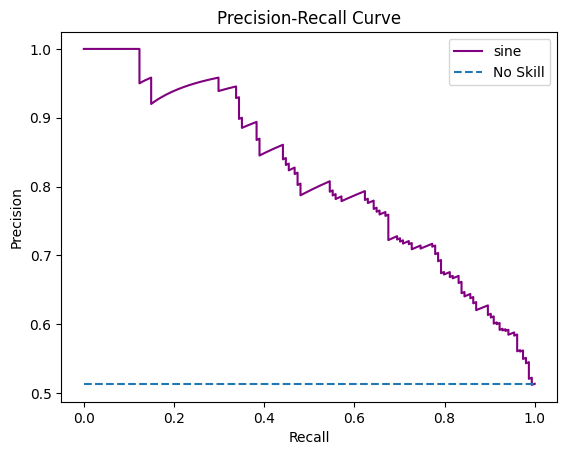

In [38]:
import io
from PIL import Image
import os
import wandb
import matplotlib.pyplot as plt
#calculate precision and recall

# os.environ["WANDB_API_KEY"] = "b21f4406f3966154b12e98de3bef934216952a54"
# os.environ["WANDB_ENTITY"]="istiyaksiddiquee"
# wandb.init(project="my-scikit-integration")

precision, recall, thresholds = precision_recall_curve(y_test, y_score)
y_test
no_skill = len(y_test[y_test==1]) / len(y_test)

#create precision recall curve
fig, ax = plt.subplots()

ax.plot(recall, precision, color='purple', label="sine")
ax.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')

#add axis labels to plot
ax.set_title('Precision-Recall Curve')
ax.set_ylabel('Precision')
ax.set_xlabel('Recall')
ax.legend()
plt.show()
#display plot
# wandb.log({"PRC-2": fig})

# # plt.savefig('PR-test.jpeg')


# img_buf = io.BytesIO()
# plt.savefig(img_buf, format='png')

# im = Image.open(img_buf)
# # im.show(title="My Image")
# wandb.log({"example-2": wandb.Image(im)})
# img_buf.close()

In [26]:
import pandas as pd 
a={'b':100,'c':300}
b={'b':200,'c':400}
df = pd.concat([pd.DataFrame(a, index=['dt']), pd.DataFrame(b, index=['dt-pos'])])
df

,b,c
dt,100,300
dt-pos,200,400


In [107]:
y_test[0].shape

(10,)

# Feature Selection

In [27]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import Lasso, LogisticRegression

scaler = StandardScaler()
scaler.fit(scaled_X_train)
sel_ = SelectFromModel(LogisticRegression(C=0.5, penalty='l1', solver='liblinear', random_state=10))
sel_.fit(scaler.transform(scaled_X_train), y_train)
removed_feats = scaled_X_train.columns[(sel_.estimator_.coef_ == 0).ravel().tolist()]
removed_feats

Index(['virality', 'structural_heterogeneity'], dtype='object')

c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py:378: FitFailedWarning: 
270 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Program Files\Python310\lib\site-packages\sklearn\model_selection\_validation.py", line 686, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 1162, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "c:\Program Files\Python310\lib\site-packages\sklearn\linear_model\_logistic.py", line 54, in _check_solver
    raise ValueEr

Text(0.5, 1.0, 'Coefficients in the Logistic Model')

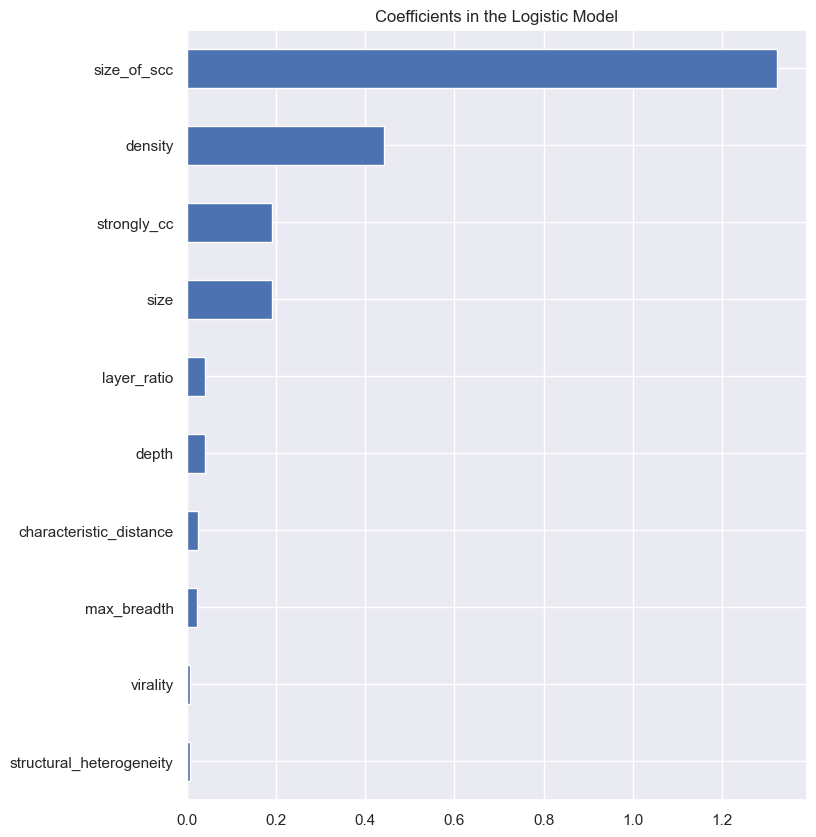

In [10]:

from sklearn.linear_model import Lasso, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedKFold, GridSearchCV
from sklearn.linear_model import Lasso
import matplotlib

clf_grid = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "C": [_ for _ in range(1, 10, 1)],
    "dual": [True, False],
}

model = LogisticRegression()

clf = GridSearchCV(
    estimator=model,
    cv=5,
    refit="average_precision_score",
    param_grid=clf_grid,
    scoring='average_precision',
    n_jobs=-1,
)

clf.fit(scaled_X_train, y_train)
coefficients = np.abs(clf.best_estimator_.coef_)

coef = pd.Series(coefficients[0], index = scaled_X_train.columns)
coef = pd.concat([coef.sort_values().head(10)])


matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
coef.plot(kind = "barh")
plt.title("Coefficients in the Logistic Model")

# sel_ = SelectFromModel(
#     LogisticRegression(C=0.5, penalty="l1", solver="liblinear", random_state=10)
# )
# sel_.fit(scaled_X_train, y_train)
# removed_feats = scaled_X_train.columns[(sel_.estimator_.coef_ == 0).ravel().tolist()]
# removed_feats

In [51]:
normalized_df.columns

Index(['depth', 'size', 'max_breadth', 'virality', 'strongly_cc',
       'size_of_scc', 'density', 'layer_ratio', 'structural_heterogeneity',
       'characteristic_distance'],
      dtype='object')

Text(0.5, 1.0, 'Coefficients in the Elastic Net Model')

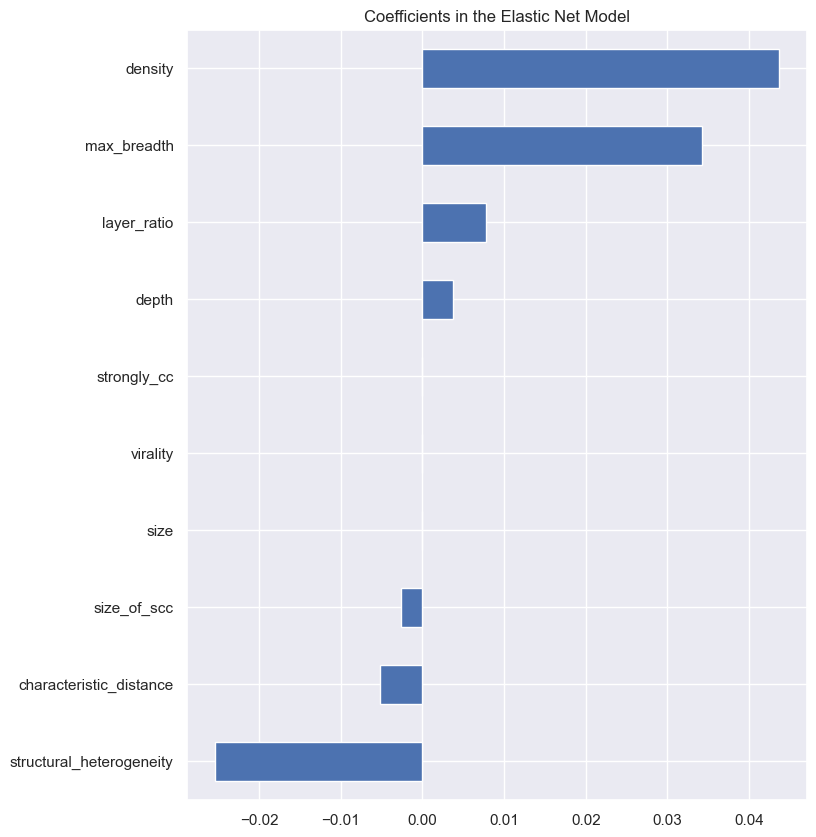

In [13]:
from sklearn.linear_model import ElasticNet
import matplotlib
import matplotlib.pyplot as plt
from numpy import arange

grid = {
    'alpha': [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0],
    'l1_ratio': arange(0, 1, 0.1)
}

model = ElasticNet()

clf = GridSearchCV(
    estimator=model,
    cv=5,
    refit="average_precision_score",
    param_grid=grid,
    scoring='average_precision',
    n_jobs=-1,
)

clf.fit(scaled_X_train, y_train)

coef = pd.Series(clf.best_estimator_.coef_, index = scaled_X_train.columns)
imp_coef = pd.concat([coef.sort_values().head(10)])

matplotlib.rcParams['figure.figsize'] = (8.0, 10.0)
imp_coef.plot(kind = "barh")
plt.title("Coefficients in the Elastic Net Model")

# arange(0, 1, 0.1)

In [14]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

# define random forest classifier
rfc = RandomForestClassifier()
boruta_selector = BorutaPy(rfc, n_estimators='auto', verbose=2, random_state=1)
boruta_selector.fit(np.array(scaled_X_train), np.array(y_train)) 

selected_rf_features = pd.DataFrame({'Feature':list(scaled_X_train.columns),
                                      'Ranking':boruta_selector.ranking_})
selected_rf_features.sort_values(by='Ranking')

Iteration: 	1 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	0
Iteration: 	2 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	0
Iteration: 	3 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	0
Iteration: 	4 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	0
Iteration: 	5 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	0
Iteration: 	6 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	0
Iteration: 	7 / 100
Confirmed: 	0
Tentative: 	10
Rejected: 	0
Iteration: 	8 / 100
Confirmed: 	0
Tentative: 	0
Rejected: 	10


BorutaPy finished running.

Iteration: 	9 / 100
Confirmed: 	0
Tentative: 	0
Rejected: 	10


,Feature,Ranking
9,characteristic_distance,2
8,structural_heterogeneity,3
3,virality,4
7,layer_ratio,5
4,strongly_cc,7
5,size_of_scc,7
6,density,7
2,max_breadth,9
1,size,10
0,depth,11


<Axes: >

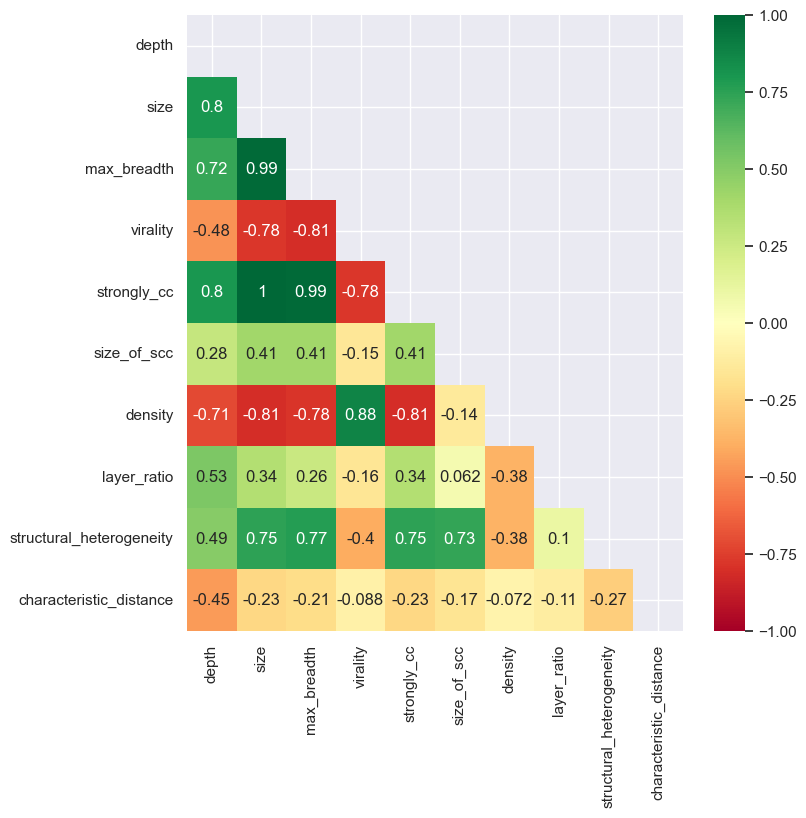

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
mask = np.triu(np.ones_like(scaled_X_train.corr(), dtype=bool))
sns.heatmap(scaled_X_train.corr(method='pearson', numeric_only = True), annot=True, mask=mask, vmin=-1, vmax=1, cmap ='RdYlGn')

In [23]:
# load statmodels functions
from statsmodels.stats.outliers_influence import variance_inflation_factor

# compute the vif for all given features
def compute_vif(df, considered_features):
    
    X = df[considered_features]
    # the calculation of variance inflation requires a constant
    X['intercept'] = 1
    
    # create dataframe to store vif values
    vif = pd.DataFrame()
    vif["Variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    vif = vif[vif['Variable']!='intercept']
    return vif

considered_features = list(scaled_X_train.columns)
considered_features.remove('size')
considered_features.remove('strongly_cc')

# considered_features.remove('max_breadth')
# considered_features.remove('size_of_scc')

# compute vif 
compute_vif(scaled_X_train, considered_features).sort_values('VIF', ascending=False)

C:\Users\istiyak\AppData\Local\Temp\ipykernel_13892\3996048997.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['intercept'] = 1


,Variable,VIF
1,max_breadth,19.054075
4,density,17.125661
2,virality,15.305356
0,depth,10.822865
6,structural_heterogeneity,8.552457
7,characteristic_distance,2.700220
3,size_of_scc,2.669756
5,layer_ratio,1.548034


In [50]:
vif = pd.DataFrame()
factors = list(scaled_X_train.columns)
factors.remove('strongly_cc')
factors.remove('size')

# vif["VIF Factor"] = [variance_inflation_factor(scaled_X_train.values, i) for i in range(scaled_X_train.shape[1])]
# vif["features"] = scaled_X_train.columns
# vif

scaled_X_train.values

array([[ 0.62206934,  0.79029878,  0.74135288, ...,  0.40507663,
         0.51252369, -0.39202693],
       [-0.70741279, -0.30636113, -0.22855404, ..., -0.42060656,
        -0.31918419,  0.87678487],
       [ 1.39976654,  0.71850685,  0.57760972, ...,  0.61149743,
         0.26064216, -0.78664852],
       ...,
       [-0.70741279, -0.30636113, -0.22855404, ..., -0.42060656,
        -0.31918419,  0.87678487],
       [-0.70741279, -0.77866685, -0.73718674, ..., -0.42060656,
        -0.5860124 , -0.39658978],
       [-0.70741279, -0.50238572, -0.43965568, ..., -0.42060656,
        -0.47676737,  0.33947287]])

In [74]:
len(list(X_train.columns))

10

In [43]:
vif_data = pd.DataFrame()

columns = list(scaled_X_train.columns)
columns.remove('strongly_cc')
columns.remove('size')


vif_data["feature"] = columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(scaled_X_train.values, i)
                          for i in range(len(columns))]
  
print(vif_data)

                    feature           VIF
0                     depth  2.225291e+01
1               max_breadth           inf
2                  virality  8.097345e+02
3               size_of_scc  3.831582e+01
4                   density  9.668642e+06
5               layer_ratio  9.668642e+06
6  structural_heterogeneity  1.950729e+01
7   characteristic_distance  1.712278e+00


c:\Program Files\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)


In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()

columns = list(scaled_X_train.columns)
# columns.remove('size')
# columns.remove('size_of_scc')
# columns.remove('strongly_cc')
vif_data["feature"] = columns

# calculating VIF for each feature
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i)
                          for i in range(len(columns))]
  
print(vif_data)

                    feature        VIF
0                     depth   2.943275
1                      size        inf
2               max_breadth  14.994902
3                  virality   6.020220
4               strongly_cc        inf
5               size_of_scc  23.609314
6                   density        inf
7               layer_ratio        NaN
8  structural_heterogeneity   7.283072
9   characteristic_distance   1.473446


c:\Program Files\Python310\lib\site-packages\statsmodels\stats\outliers_influence.py:198: RuntimeWarning: divide by zero encountered in double_scalars
  vif = 1. / (1. - r_squared_i)
c:\Program Files\Python310\lib\site-packages\statsmodels\regression\linear_model.py:1781: RuntimeWarning: invalid value encountered in double_scalars
  return 1 - self.ssr/self.centered_tss


In [30]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

rfe_selector = RFE(estimator=RandomForestClassifier(), n_features_to_select=8, step=1, verbose=5)
rfe_selector.fit(scaled_X_train, y_train)
rfe_support = rfe_selector.get_support()
rfe_feature = scaled_X_train.loc[:,rfe_support].columns.tolist()
print(str(len(rfe_feature)), 'selected features')
print(rfe_feature)

Fitting estimator with 10 features.
Fitting estimator with 9 features.
8 selected features
['size', 'max_breadth', 'virality', 'size_of_scc', 'density', 'layer_ratio', 'structural_heterogeneity', 'characteristic_distance']


In [38]:
rfe_selector.ranking_

array([3, 1, 1, 1, 2, 1, 1, 1, 1, 1])

In [ ]:
feature_selection_df = pd.DataFrame({'Feature':feature_name, 'Pearson':cor_support, 'Chi-2':chi_support, 'RFE':rfe_support, 'Logistics':embeded_lr_support,
                                    'Random Forest':embeded_rf_support, 'LightGBM':embeded_lgb_support})
# count the selected times for each feature
feature_selection_df['Total'] = np.sum(feature_selection_df, axis=1)
# display the top 100
feature_selection_df = feature_selection_df.sort_values(['Total','Feature'] , ascending=False)
feature_selection_df.index = range(1, len(feature_selection_df)+1)
feature_selection_df.head(num_feats)

In [ ]:
considered_features = ['max_breadth', 'density', 'virality', 'depth', 'structural_heterogeneity', 'characteristic_distance', 'size_of_scc', 'layer_ratio']

# Feature Scaling

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
 
# To scale data
scaled_X_train = scaler.fit_transform(X_train)

In [ ]:
features = load_diabetes()['feature_names']
pipeline = Pipeline([
                     ('scaler',StandardScaler()),
                     ('model',Lasso())
])
search = GridSearchCV(pipeline,
                      {'model__alpha':np.arange(0.1,10,0.1)},
                      cv = 5, scoring="neg_mean_squared_error",verbose=3
                      )
search.fit(X_train,y_train)
search.best_params_
coefficients = search.best_estimator_.named_steps['model'].coef_

importance = np.abs(coefficients)
np.array(features)[importance > 0]
np.array(features)[importance == 0]